In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import seaborn as sns
from PIL import Image


In [2]:
categories = ['Cat', 'Dog']
x = []
y = []

for c in categories:
    path = 'PetImages/' + c
    label = 0 if c == 'Cat' else 1
    for image in os.listdir(path):
        try:
            img_path = path + "/" + image
            img = Image.open(img_path).convert('L').resize((64,64))
            x.append(np.array(img).flatten())
            y.append(label)
        except:
            continue
x = np.array(x)
y = np.array(y)
print(len(x))


c:\Users\yorba\Downloads\jake\data-science\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


24998


In [3]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state=66)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [4]:
model = MLPClassifier(hidden_layer_sizes=[300, 100], activation= 'relu', random_state= 13, verbose=True, early_stopping= True)

In [5]:
pca = PCA(n_components= 100, whiten= True, random_state= 66)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.fit_transform(x_test_scaled)

In [6]:
%time model.fit(x_train_pca, y_train)

Iteration 1, loss = 0.67940376
Validation score: 0.602500
Iteration 2, loss = 0.61555838
Validation score: 0.652000
Iteration 3, loss = 0.56028367
Validation score: 0.654500
Iteration 4, loss = 0.50589433
Validation score: 0.665000
Iteration 5, loss = 0.45677623
Validation score: 0.661000
Iteration 6, loss = 0.41458946
Validation score: 0.663000
Iteration 7, loss = 0.37243982
Validation score: 0.668000
Iteration 8, loss = 0.33449830
Validation score: 0.665500
Iteration 9, loss = 0.30069675
Validation score: 0.665500
Iteration 10, loss = 0.26274011
Validation score: 0.653500
Iteration 11, loss = 0.22754954
Validation score: 0.659500
Iteration 12, loss = 0.19924947
Validation score: 0.658500
Iteration 13, loss = 0.16736138
Validation score: 0.654500
Iteration 14, loss = 0.14536870
Validation score: 0.652500
Iteration 15, loss = 0.12224011
Validation score: 0.647500
Iteration 16, loss = 0.09866633
Validation score: 0.645000
Iteration 17, loss = 0.08477300
Validation score: 0.650000
Iterat

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[300, 100]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",13


In [7]:
print(model.score(x_test_pca, y_test))

0.5458


prediction: Dog
confidence: Cat: 0.26, Dog: 0.74


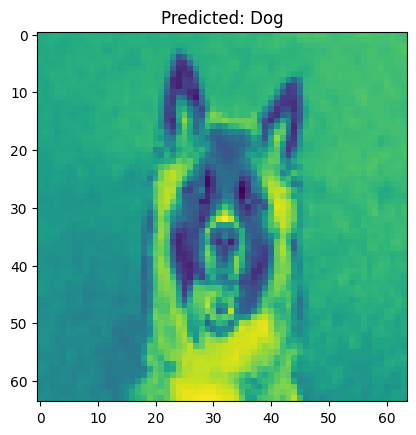

In [ ]:
def predict_image(img_path):
    img = Image.open(img_path).convert('L').resize((64, 64))
    img_flat = np.array(img).flatten().reshape(1,-1)
    scaled_img = scaler.transform(img_flat)
    img_pca = pca.transform(scaled_img)
    prediction = model.predict(img_pca)
    probability = model.predict_proba(img_pca)

    label = 'Cat' if prediction[0] == 0 else "Dog"
    print(f"prediction: {label}")
    print(f"confidence: Cat: {probability[0][0]:.2f}, Dog: {probability[0][1]:.2f}")
    plt.imshow(img)
    plt.title(f'Predicted: {label}')
    plt.show()

# predict_image("dog 2.jpg")
# predict_image("dog image.jpg")
# predict_image("cat.jpg")
# predict_image("cat 2.jpg")
# predict_image("calc.jpg")
# predict_image('scratch.png')
# predict_image("cat test.jpg")
# predict_image("dog real.webp")